# Анализ аудитории витуберов

Посмотрим ключевую статистику комьюнити витуберов:

**Что сделано**:

* Рост аудитории
* Уникальность витуберов
* Кластеризация витуберов
* Количество локальных фолловов у зрителей выборки
* Количество глобальных фолловов у зрителей выборки

**Что пока нет**:

* Граф самых близости витуберов (то есть если косинусное расстояние меньше какого-то порога, то рисовать ребро, иначе - нет)
* Размер активной аудитории
* Активность чата
* Кластеризация сообщений в чате

#### Импорт всего нужного

In [1]:
import os
import csv
import sys
sys.path.insert(1, '../util/')

from data import UserData, FollowerData
from userdata import get_userdata, get_userdata_by_login
from followers import get_followers

import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np
import sklearn
from datetime import datetime
from typing import Optional, List, Tuple, Dict
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass

## Prepare data

In [2]:
VTUBERS_LIST_FILE_PATH = "./data/vtubers.txt"

In [45]:
@dataclass
class VtubersData:
    vtuber_names: List[str] # 1 x N
    vtuber_followers: Dict[str, List[FollowerData]]
    user_following: Dict[int, List[str]]

In [4]:
vtuber_names = set()

with open(VTUBERS_LIST_FILE_PATH, 'r') as data_file:
    for line in data_file.readlines():
        if line.startswith("#"): # comment:
            continue
        vtuber_names.add(line.lower().strip())

vtuber_names = list(vtuber_names)

In [ ]:
# Check if all vtubers exists
counter = 0
for vtuber in vtuber_names:
    counter += 1
    print(f"[{counter}/{len(vtuber_names)}] Check vtuber {vtuber}")
    assert get_userdata_by_login(vtuber) is not None

In [5]:
print(f"Loaded {len(vtuber_names)} vtubers")

Loaded 254 vtubers


In [6]:
def get_cache_path():
    current_date = datetime.now()

    return os.path.join("data/", 
                        ".temp/",
                        f"followers_{current_date.year}_{current_date.month}_{current_date.day}.txt")


def load_followers_data(vtuber_names: List[str],
                        online: bool = False, 
                        num_workers: int = 32,
                        cache_path: str = get_cache_path()):
    if online:
        def load_followers_execution(vtuber_login: str) -> Tuple[str, Optional[List[FollowerData]]]:
            result = get_followers(vtuber_login, log=True, repeat_times=5, repeat_delay=1.0)
            if result is None:
                print("[ERROR]", "Failed loading vtuber", vtuber_login, "attempt", i)
            else:
                return vtuber_login, result


        vtuber_followers = {}
        with ThreadPoolExecutor(max_workers=num_workers) as executor:
            futures = []

            for vtuber in vtuber_names:
                future = executor.submit(load_followers_execution, vtuber_login=vtuber)
                futures.append(future)
            
            for future in as_completed(futures):
                vtuber_login, followers_result = future.result()
                if followers_result is None:
                    print(f"Cannot load `{vtuber_login}` result")
                else:
                    empty_results = list(filter(lambda el: el.user is None, followers_result))
                    print(f"Got `{vtuber_login}` result, empty results: {len(empty_results)}/{len(followers_result)}")
                vtuber_followers[vtuber_login] = followers_result
        
        return vtuber_followers
    else:
        result = {}

        with open(cache_path, 'r') as cache_file:
            csvreader = csv.DictReader(cache_file, delimiter=',')

            for row in csvreader:
                vtuber = row['vtuber']
                followed_at = datetime.fromisoformat(row['followed_at'])
                if row['id']:
                    id              = int(row['id'])
                    login           = None if row['login'] == "None" else row['login']
                    created_at      = None if row['created_at'] == "None" else datetime.fromisoformat(row['created_at'])
                    deleted_at      = None if row['deleted_at'] == "None" else datetime.fromisoformat(row['deleted_at'])
                    follows_count   = int(row['follows_count'])
                    user_data = UserData(id=id,
                                        login=login,
                                        created_at=created_at,
                                        deleted_at=deleted_at,
                                        follows_count=follows_count)
                else:
                    user_data = None
                follower_data = FollowerData(user=user_data,
                                            followed_at=followed_at)
                
                if vtuber not in result.keys():
                    result[vtuber] = []
                result[vtuber].append(follower_data)
        
        return result


def cache_followers_data(vtuber_followers: Dict[str, List[FollowerData]],
                        cache_path: str = get_cache_path()):
    with open(cache_path, 'w') as cache_file:
        csvwriter = csv.writer(cache_file, delimiter=',')
        csvwriter.writerow(["vtuber",
                            "followed_at",
                            "id",
                            "login",
                            "created_at",
                            "deleted_at",
                            "follows_count"])

        for (vtuber, value) in vtuber_followers.items():
            for follower_data in value:
                if follower_data.user is None:
                    csvwriter.writerow([vtuber,
                                        follower_data.followed_at,
                                        "",
                                        "",
                                        "",
                                        "",
                                        ""])
                else:
                    csvwriter.writerow([vtuber,
                                        follower_data.followed_at,
                                        follower_data.user.id,
                                        follower_data.user.login,
                                        str(follower_data.user.created_at),
                                        str(follower_data.user.deleted_at),
                                        follower_data.user.follows_count])

In [9]:
vtuber_followers = load_followers_data(vtuber_names, online=False, num_workers=64, cache_path="./data/.temp/followers_2025_11_3.txt")

In [10]:
for vtuber in vtuber_names:
    assert vtuber_followers[vtuber] is not None

In [ ]:
cache_followers_data(vtuber_followers)

In [14]:
user_following = {}

for vtuber in vtuber_names:
    for follower in vtuber_followers[vtuber]:
        if follower.user is not None:
            user_name = follower.user.id
            if user_name not in user_following.keys():
                user_following[user_name] = []
            user_following[user_name].append(vtuber)

In [18]:
data = VtubersData(vtuber_names=vtuber_names, vtuber_followers=vtuber_followers, user_following=user_following)

## Графики роста аудитории

### График фолловов

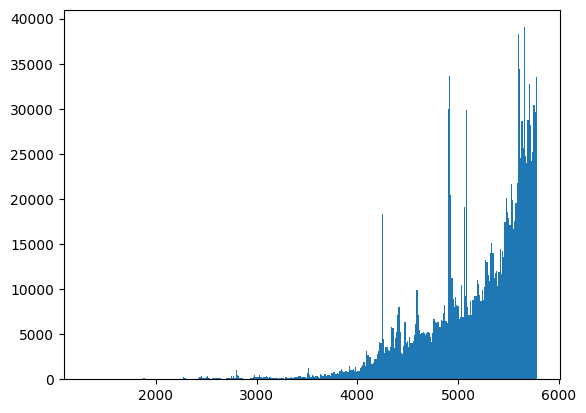

In [20]:
sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = []
for vtuber in data.vtuber_names:
    followers = data.vtuber_followers[vtuber]
    for follower in followers:
        auditory_data.append(follower)

auditory_data = list(map(lambda viewer: viewer.followed_at, auditory_data))
auditory_data = list(map(lambda follow_date: follow_date - sunce_date, auditory_data))
auditory_data = list(map(lambda follow_timedelta: follow_timedelta.days, auditory_data))
auditory_data = np.array(auditory_data)

plt.hist(auditory_data, bins="auto", log=False, cumulative=False)
plt.show() 

### График фолловеров без причин резких скачков

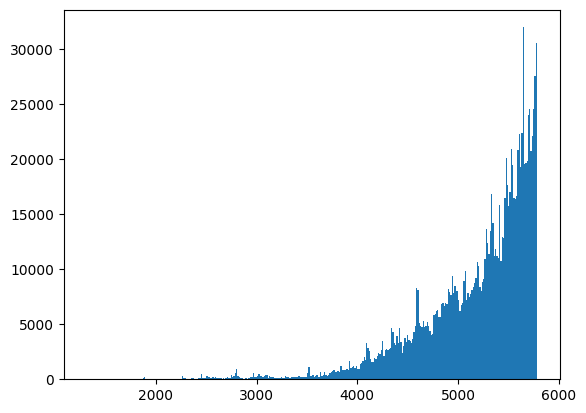

In [25]:
IGNORED_VTUBERS = ['xkamysh', 'qchaan_9', 'rera_seal', "trixie_vox", "lerritay"]

sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = []
for vtuber in data.vtuber_names:
    if vtuber in IGNORED_VTUBERS:
        continue
    
    followers = data.vtuber_followers[vtuber]
    for follower in followers:
        auditory_data.append(follower)

auditory_data = list(map(lambda viewer: viewer.followed_at, auditory_data))
auditory_data = list(map(lambda follow_date: follow_date - sunce_date, auditory_data))
auditory_data = list(map(lambda follow_timedelta: follow_timedelta.days, auditory_data))
auditory_data = np.array(auditory_data)

plt.hist(auditory_data, bins="auto", log=False, cumulative=False)
plt.show() 

### Рост уникальных фолловов

То есть не учитываются второй, третий и т.д. фолловы от одного и того же человека

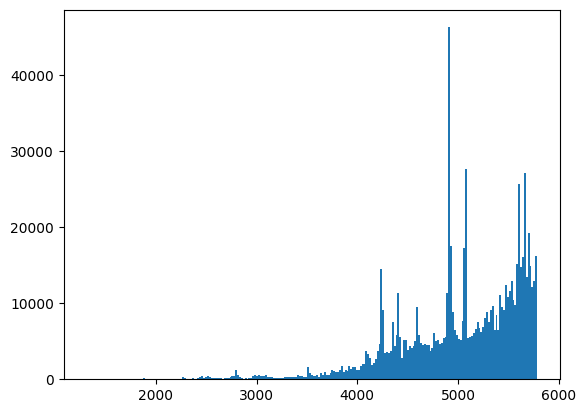

In [26]:
sunce_date = datetime.fromisoformat("2010-01-01 00:00:00.000000+00:00")
auditory_data = {}
for vtuber in data.vtuber_names:
    followers = data.vtuber_followers[vtuber]
    for follower in followers:
        if follower.user is not None:
            if follower.user.login not in auditory_data.keys():
                auditory_data[follower.user.login] = follower.followed_at
            auditory_data[follower.user.login] = min(auditory_data[follower.user.login], follower.followed_at)

auditory_data = auditory_data.values()
auditory_data = list(map(lambda follow_date: follow_date - sunce_date, auditory_data))
auditory_data = list(map(lambda follow_timedelta: follow_timedelta.days, auditory_data))
auditory_data = np.array(auditory_data)

plt.hist(auditory_data, bins="auto", log=False, cumulative=False)
plt.show() 

### Уникальность витуберов

Посмотрим, какая часть аудитории витубера смотрит только его 

In [46]:
print(len(data.user_following))

832562


In [47]:
unique_users = list(filter(lambda fd: len(fd[1]) <= 1, data.user_following.items()))
print(len(unique_users))

633374


In [48]:
vtuber_unique_followers_counter = {}
for (user, following) in unique_users:
    vtuber_name = following[0]
    vtuber_unique_followers_counter[vtuber_name] = vtuber_unique_followers_counter.get(vtuber_name, 0) + 1

vtuber_unique_followers_proportion = {}
for (vtuber, unique_followers) in vtuber_unique_followers_counter.items():
    vtuber_unique_followers_proportion[vtuber] = unique_followers / len(data.vtuber_followers[vtuber]) * 100

sorted(vtuber_unique_followers_proportion.items(), 
       key=lambda el: el[1], 
       reverse=True)

[('kepa_mita', 94.27999514739778),
 ('vvelenavv', 87.29874776386404),
 ('mad_demian', 84.39920336357602),
 ('bready_xo', 83.01578660860099),
 ('natakodo', 80.40718237054503),
 ('trixie_vox', 78.93781499623452),
 ('lastglance_', 76.48858554954107),
 ('lerritay', 73.88113853543871),
 ('conway671', 70.2707136997539),
 ('gishichi', 68.2753164556962),
 ('raw_rawfler', 64.8538961038961),
 ('madvaverka', 64.15694591728526),
 ('kashtan_mp4', 63.486299108616706),
 ('henmimori', 63.14736052039029),
 ('boopa', 61.27007844602167),
 ('nyapuru', 61.184417216462464),
 ('yui_cake', 60.240290583962),
 ('piwochan', 60.003084991516275),
 ('ananastya_nastya', 59.62503550800113),
 ('mukubae', 59.48062654575432),
 ('naxajlka', 58.867819297267154),
 ('linamyth', 58.740053050397876),
 ('amikirisan', 58.581779308706494),
 ('lightfoxmanga', 57.592503604036516),
 ('ixxxiq', 56.84657671164418),
 ('nastramoonlight', 55.08281909710945),
 ('nekisekai', 53.459413183905355),
 ('puhnyasha', 53.15495207667732),
 ('novik

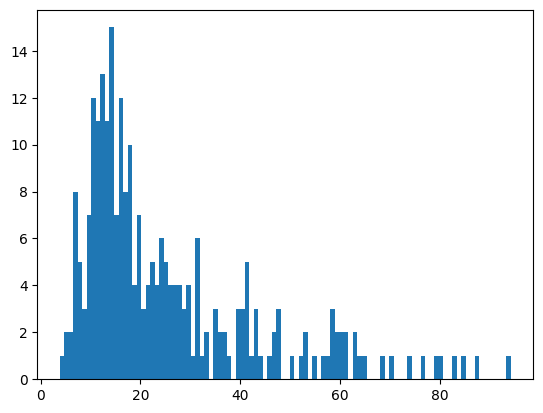

In [49]:
plt.hist(vtuber_unique_followers_proportion.values(), bins=100)
plt.show()

| Vtuber | Statistics | Description |
| --- | --- | --- |
| mad_demian | 3855/4519 85% | в хиатусе |
| bready_xo | 4625/5512 83% | в хиатусе |
| natakodo | 18171/22059 82% | в хиатусе |
| lastglance_ | 3371/4250 79% | в хиатусе |
| gishichi | 886/1264 70% | англо витубер??? |
| kashtan_mp4 | 2030/2982 68% | Ich weiß nicht |
| nyapuru | 8657/12733 67% | мужыыыыык |
| mukubae | 1613/2429 66% | в хиатусе |
| boopa | 8545/13370 63% | Ich weiß nicht |
| linamyth | 4732/7542 62% | в хиатусе |
| ananastya_nastya | 6511/10562 61% | Лига легендер |
| amikirisan | 5176/8408 61% | Ich weiß nicht |
| piwochan | 3942/6485 60% | Ich weiß nicht |
| naxajlka | 2142/3588 59% | Ich weiß nicht |
| lightfoxmanga | 4903/8276 59% | мужыыыыык |
| quinella_admin | 8864/15398 57% | Ich weiß nicht |
| vernirra | 10568/18474 57% | Ich weiß nicht |
| planyach | 26256/46423 56% | Ich weiß nicht |
| nekisekai | 7131/12849 55% | Ich weiß nicht |
| nnstreamercha | 2546/4724 53% | мужыыыыык |
| mamilokuchii | 8751/17174 50% | Лигалегендер, любимый у дедпи |
| yumekomoore | 15773/31344 50% | Ich weiß nicht |

In [52]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "Followers": list(map(lambda vtuber: len(data.vtuber_followers[vtuber]), data.vtuber_names)),
    "Unique followers (%)": list(map(lambda vtuber: vtuber_unique_followers_proportion[vtuber], data.vtuber_names)),
    "vtuber": data.vtuber_names
})
fig = px.scatter(df, x="Followers", y="Unique followers (%)", hover_name="vtuber")
fig.show()

### Кластеризация витуберов

#### Векторизация данных

In [53]:
columns = data.user_following.keys()
user_id_to_column = {}
for (i, col) in zip(range(len(columns)), columns):
    user_id_to_column[col] = i

def vtuber2vec(vtuber: str) -> np.ndarray:
    result = np.zeros(len(data.user_following))
    for follower in data.vtuber_followers[vtuber]:
        if follower.user is not None:
            result[user_id_to_column[follower.user.id]] = 1
    
    return result

In [55]:
dataset = []
for vtuber in data.vtuber_names:
    dataset.append(vtuber2vec(vtuber))
dataset = np.array(dataset)

#### Кластеризация и отрисвка

##### Косинусное расстояние

In [56]:
labels = sklearn.cluster.HDBSCAN(min_cluster_size=2, max_cluster_size=100, metric="cosine").fit_predict(X=dataset)

In [60]:
projection = sklearn.manifold.TSNE(metric="cosine", random_state=22).fit_transform(dataset)

In [58]:
data_frame = pd.DataFrame({
    "x": projection[:, 0],
    "y": projection[:, 1],
    "Кластер": labels,
    "Имя": data.vtuber_names
})
data_frame["Кластер"] = data_frame["Кластер"].astype(str) #convert to string

In [61]:
fig = px.scatter(data_frame, 
                 x="x", 
                 y="y",
                 color="Кластер", 
                 hover_name="Имя")
fig.show()

### Анализ количества фолловов у зрителей

#### Количество глобальных фолловов

In [63]:
unique_users = []
used_logins = set()
for vtuber in data.vtuber_names:
    for follower_data in data.vtuber_followers[vtuber]:
        if follower_data.user is not None and follower_data.user.login not in used_logins:
            used_logins.add(follower_data.user.login)
            unique_users.append(follower_data.user)

In [65]:
draw_data = unique_users
draw_data = list(map(lambda el: el.follows_count, draw_data))
draw_data = list(filter(lambda el: el < 100, draw_data))
df = pd.DataFrame({
    "Following": draw_data
})
fig = px.histogram(df, x="Following")
fig.show()

#### Количество локальных фолловов

In [70]:
draw_data = data.user_following.items()
draw_data = list(map(lambda el: el[1], draw_data))
draw_data = list(map(lambda el: len(el), draw_data))
draw_data = list(filter(lambda el: el > 0, draw_data))
df = pd.DataFrame({
    "Following": draw_data
})
fig = px.histogram(df, x="Following")
fig.show()

#### Количество абсолютных уникалов среди фолловеров

In [71]:
follows_count = []
abs_unique = []
for vtuber in data.vtuber_names:
    follows_count.append(len(data.vtuber_followers[vtuber]))
for vtuber in data.vtuber_names:
    vtuber_abs_unique = 0
    for follower in data.vtuber_followers[vtuber]:
        if follower.user is not None and follower.user.follows_count == 1:
            vtuber_abs_unique += 1
    abs_unique.append(vtuber_abs_unique)
abs_unique = np.array(abs_unique)
follows_count = np.array(follows_count)

df = pd.DataFrame({
    "Absolutely unique followers (%)": abs_unique / follows_count * 100,
    "Followers": follows_count,
    "Vtuber": vtuber_names,
})
fig = px.scatter(df, x="Followers", y="Absolutely unique followers (%)", hover_name="Vtuber")
fig.show()